<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head(10)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


industry_df=df.copy()
print('NaN values before cleaning:', industry_df['Industry'].isnull().sum())
industry_df=industry_df.dropna(subset=['Industry'], axis=0)                   #dropping null values because
print('NaN values after cleaning:', industry_df['Industry'].isnull().sum())

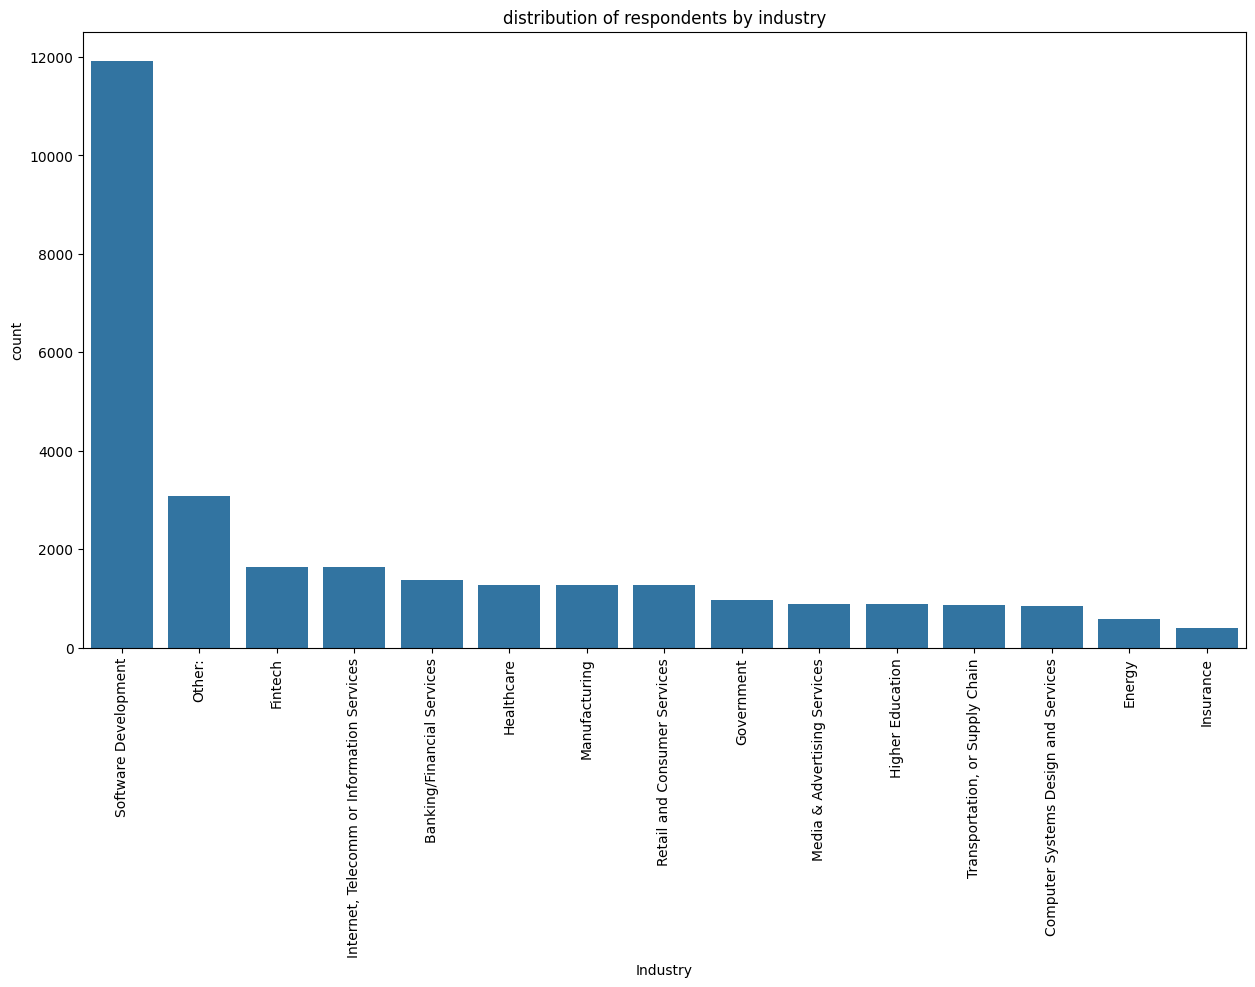

In [3]:
##Write your code here
plt.figure(figsize=(15,8))
sns.countplot(x=df['Industry'], order=df['Industry'].value_counts().index)
plt.title('distribution of respondents by industry')
plt.xticks(rotation=90)
plt.show()

In [4]:
df['Industry'].describe()

count                    28858
unique                      15
top       Software Development
freq                     11918
Name: Industry, dtype: object

In [5]:
df['Industry'].value_counts()

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64

Software Development is the dominant industry among respondents. In contrast, industries such as Energy and Insurance are noticeably underrepresented. A significant number of respondents selected the “Other” category, suggesting that the survey options may not fully capture all industries. It is also important to note that over 35,000 respondents did not answer this question, which should be considered when interpreting the distribution.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [6]:
df_comp=df.copy()
print('NaN values before cleaning:', df_comp['ConvertedCompYearly'].isnull().sum())
df_comp=df_comp.dropna(subset=['ConvertedCompYearly'],axis=0)                             # Dropping null values because this data is crucial for analysis and it will improve code execution
print('NaN values after cleaning:', df_comp['ConvertedCompYearly'].isnull().sum())

NaN values before cleaning: 42002
NaN values after cleaning: 0


In [7]:
##Write your code here
comp=df_comp['ConvertedCompYearly']

comp_mean=comp.mean()
comp_std=comp.std()
comp_median=comp.median()

print('compensation mean:', comp_mean,'\t compensation standard deviation:', comp_std, '\t compensation median:', comp_median)

outliers=comp[comp>(comp_mean+3*comp_std)]
outliers

compensation mean: 86155.28726264134 	 compensation standard deviation: 186756.97308629754 	 compensation median: 65000.0


529       650000.0
828      1000000.0
1932      945000.0
2171      750000.0
2187     2000000.0
           ...    
38219    1000000.0
39643    1300000.0
40066     800000.0
40952     750000.0
41027     700000.0
Name: ConvertedCompYearly, Length: 89, dtype: float64

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


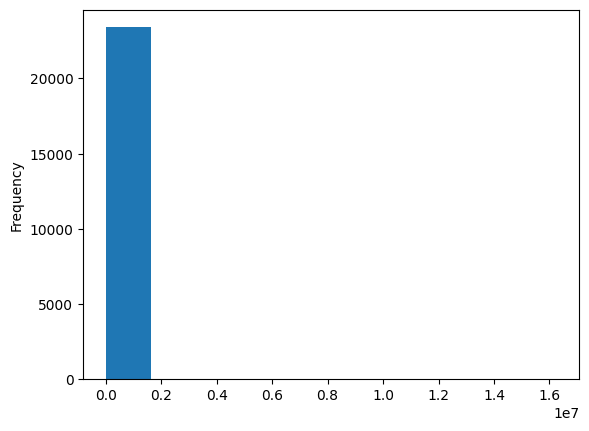

In [8]:
comp.plot(kind='hist')
plt.show()

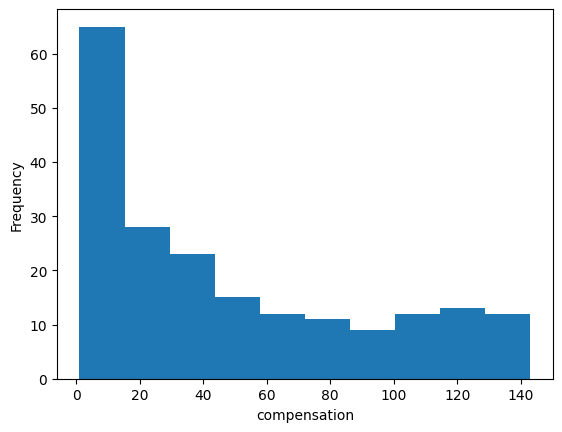

In [9]:
comp_sorted=comp.sort_values()
comp_sorted[0:200].plot(kind='hist')
plt.xlabel('compensation')
plt.show()

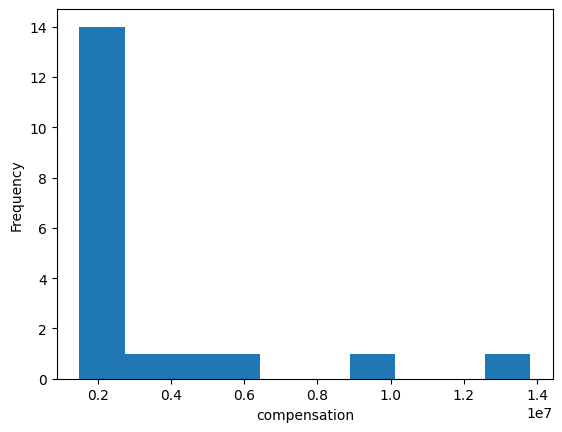

In [10]:
comp_sorted[-20:-1].plot(kind='hist')
plt.xlabel('compensation')
plt.show()

In [11]:
##Write your code here
Q1=np.quantile(comp, 0.25)
Q3=np.quantile(comp, 0.75)
IQR=Q3-Q1

print('IQR value:', IQR)

upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR
print('lower bound', lower_bound, '\t upper bound', upper_bound)

print('\n\n before deleting outliers \n\n\n', df_comp['ConvertedCompYearly'].describe())
df_comp_clean=df_comp[(
    (comp>lower_bound) &
    (comp<upper_bound)
)]
    
print('\n\n\n shape after deleting outliers \n\n', df_comp_clean['ConvertedCompYearly'].describe())    # broader analysis of this column is in data_wrangling/09_imput_missing_values
print('\n\n number od deleted outliers:', df_comp.shape[0]-df_comp_clean.shape[0])

IQR value: 75259.5
lower bound -80177.25 	 upper bound 220860.75


 before deleting outliers 


 count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64



 shape after deleting outliers 

 count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64


 number od deleted outliers: 978


Using the standard 1.5×IQR rule, 978 observations (~4% of the data) were identified as outliers and removed. The distribution remains right-skewed but is less affected by extreme values, making the data more suitable for further analysis.

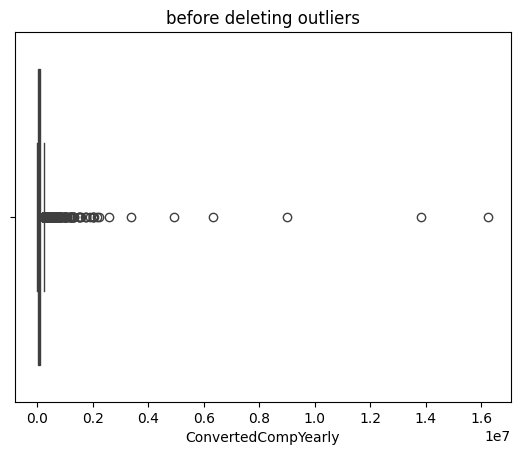

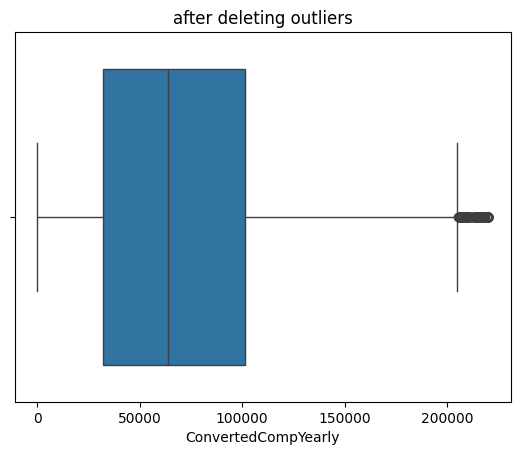

In [12]:
sns.boxplot(x=df_comp['ConvertedCompYearly'])
plt.title('before deleting outliers')
plt.show()

sns.boxplot(x=df_comp_clean['ConvertedCompYearly'])
plt.title('after deleting outliers')
plt.show()

<h3>Step 5: Create a New DataFrame</h3>



- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [13]:
##Write your code here

df_comp_clean.shape

(22457, 114)

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [14]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [15]:
##Write your code here
age_df=df.copy()

print('Prefer not to say before cleaning:', (age_df['Age']=='Prefer not to say').sum())
age_df=age_df.drop(age_df[age_df['Age']=='Prefer not to say'].index, axis=0)                 #deleting this value to convert this column from object type to float
print('Prefer not to say after cleaning:',  (age_df['Age']=='Prefer not to say').sum())

age_df['Age']=age_df['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_df['Age']=pd.to_numeric(age_df['Age'], errors='coerce')


Prefer not to say before cleaning: 322
Prefer not to say after cleaning: 0


In [16]:
numeric_col=age_df.select_dtypes(include=["float64", "int64"]).columns
numeric_col

Index(['ResponseId', 'Age', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'],
      dtype='str')

In [17]:
for col in numeric_col:
    print(f'correlation between age and {col} \n')
    print(age_df[['Age', col]].corr(method='spearman'), '\n\n\n\n\n')  # Replaced Pearson with Spearman correlation. Since the age variable is grouped into 7 ranks, it does not meet the linearity assumption required for Pearson.

correlation between age and ResponseId 

                 Age  ResponseId
Age         1.000000   -0.040304
ResponseId -0.040304    1.000000 





correlation between age and Age 

     Age  Age
Age  1.0  1.0
Age  1.0  1.0 





correlation between age and CompTotal 

                Age  CompTotal
Age        1.000000   0.143621
CompTotal  0.143621   1.000000 





correlation between age and WorkExp 

              Age   WorkExp
Age      1.000000  0.822078
WorkExp  0.822078  1.000000 





correlation between age and JobSatPoints_1 

                     Age  JobSatPoints_1
Age             1.000000        0.038366
JobSatPoints_1  0.038366        1.000000 





correlation between age and JobSatPoints_4 

                     Age  JobSatPoints_4
Age             1.000000       -0.028558
JobSatPoints_4 -0.028558        1.000000 





correlation between age and JobSatPoints_5 

                     Age  JobSatPoints_5
Age             1.000000       -0.050527
JobSatPoints_5 -0.050527      

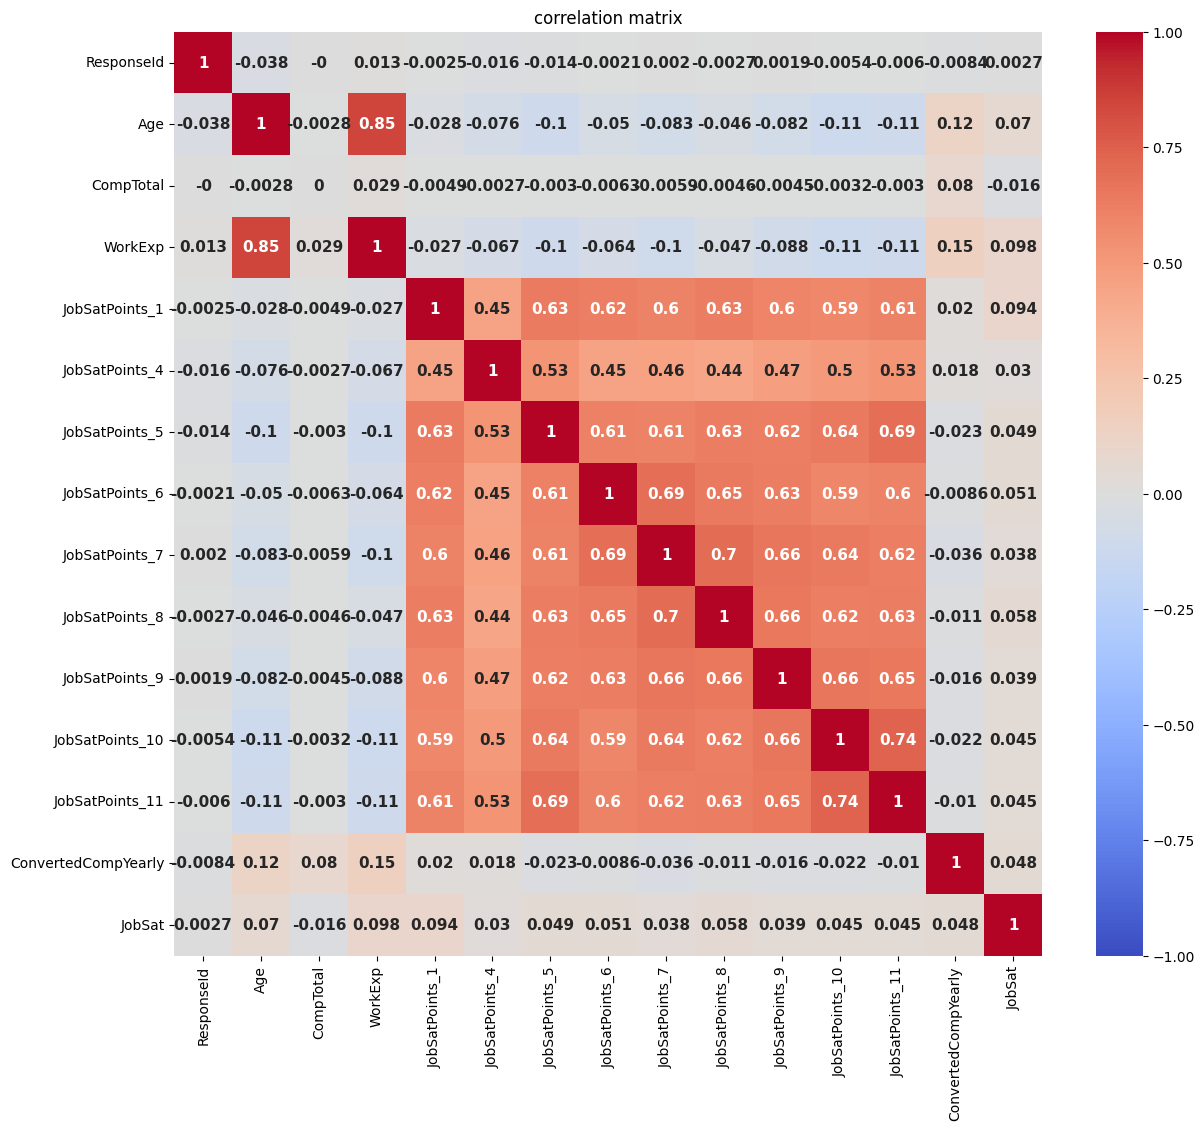

In [18]:
plt.figure(figsize=(14,12))
sns.heatmap(age_df[numeric_col].corr(), cmap='coolwarm', annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, vmin=-1, vmax=1)
plt.title('correlation matrix')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
